In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.seterr(over='ignore', invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [4]:
# Código
def jacobi(A, b, tol=1e-12, max_iter=1000):
    # Palpite inicial
    x_k = np.zeros(b.size)
    
    # Dividir A em L, D e U
    d = np.diag(A)
    D = np.diag(d)
    L_plus_U = (A - D)
    
    x_errors = []
    residual_errors = []
    
    # Implementando as iterações
    for _ in range(max_iter):
        # Dividir elemento a elemento as linhas pelo vetor d é o mesmo que multiplicar por D^(-1)
        x_k_plus_1 = (b - L_plus_U @ x_k) / d    
    
        # Calculando os erros associados a cada iteração
        delta_steps = np.linalg.norm(x_k_plus_1 - x_k)
        residual_norm = np.linalg.norm(b - A @ x_k_plus_1)
    
        x_errors.append(delta_steps)
        residual_errors.append(residual_norm)

        # Atualizando o palpite
        x_k = x_k_plus_1
        
        # Verificando se o método já convergiu o suficiente
        if (delta_steps < tol) or (residual_norm < tol):
            break

    return x_k, np.array(x_errors), np.array(residual_errors)

#===============================================================
#===============================================================
#===============================================================

def gauss_seidel(A, b, tol=1e-12, max_iter=1000):
    b_size = b.size
    
    # Palpite inicial
    x_k = np.zeros(b_size)
    # Inicializando o x da próxima iteração
    x_k_plus_1 = np.zeros(b_size)
    
    x_errors = []
    residual_errors = []
    
    # Implementando as iterações
    for _ in range(max_iter):
                
        for i in range(b_size):
            aux_x_k = A[i, (i+1):] @ x_k[(i+1):]
                
            aux_x_k_plus_1 = A[i, :i] @ x_k_plus_1[:i]
                
            x_k_plus_1[i] = (b[i] - aux_x_k - aux_x_k_plus_1) / A[i, i]
        
        # Calculando os erros associados a cada iteração
        delta_steps = np.linalg.norm(x_k_plus_1 - x_k)
        residual_norm = np.linalg.norm(b - A @ x_k_plus_1)
    
        x_errors.append(delta_steps)
        residual_errors.append(residual_norm)
        
        x_k = x_k_plus_1.copy()
        
        # Verificando se o método já convergiu o suficiente
        if (delta_steps < tol) or (residual_norm < tol):
            break
    
    return x_k, np.array(x_errors), np.array(residual_errors)

Qual deveria ser a complexidade computacional do código que você escreveu?

## Método de Jacobi
Considere $A$ uma matriz $n \times n$
Na função referente a esse método, calculei a complexidade separadamente:
- **Pré-loop**: Aqui, calculei uma complexidade de $2n^2 + 2n + 5$ apenas contando as operações feitas. Assim, essa parte tem uma complexidade associada de $O(n^2)$.

- **Loop**: Nessa parte é a que de fato fazemos os cálculos com os vetores e matrizes. Desse modo, analisando a equação de iteração, fazemos nela uma multiplicação de matriz com vetor, uma subtração de vetores e uma divisão de cada elemento do vetor. Logo, esse componente vai ter um custo de $(2n -1) \cdot n + n + n = 2n^2 + n$, ou seja, complexidade $O(n^2)$. Além disso, na parte de calcular o ```delta_step``` (norma da subtração de dois vetores) teremos que fazer $2n + 1$ operações, resultando em uma complexidade de $O(n)$. Aliás, no próximo cálculo da norma há uma multiplicação de matriz por vetor, aumentando a complexidade dessa operação para $O(n^2)$. No restante, são apenas custos constantes.

Portanto, no final das contas, a complexidade de uma iteração desse algoritmo implementado é de $O(n^2)$. Como o algoritmo executa $k$ iterações até que o critério de convergência seja atingido (onde $k$ depende da matriz e da tolerância exigida), a complexidade computacional total do algoritmo de Jacobi implementado é de $O(k \cdot n^2)$.

## Método de Gauss-Seidel
Considere, de novo, uma matriz $A_{n \times n}$.
Vamos seguir o mesmo raciocínio:
- **Pré-Loop**: Aqui a complexidade já é menor que do método de Jacobi, pois são feitas: uma operação com custo 1, duas com custo $n$ e duas com custo 1. Assim, essa parte tem complexidade $O(n)$.

- **Loop**: Agora fazemos as iterações e calculamos sequencialmente o $x^{(k+1)}$. Isso porque, diferentemente de Jacobi, para implementar esse método com a inversa de $(D+L)$ nos custaria uma complexidade $O(n^3)$, e é exatamente isso que queremos evitar. Dessa forma, em cada iteração vai nos custar: $2n^2 + 3n$ pelas operações de calcular ```aux_x_k``` e ```aux_x_k_plus_1``` e $2n^2 + 4n + 6$ pelas operações de calcular os erros (há uma multiplicação de matriz por vetor, adicionando o termo quadrático) e atribuições. Logo, a complexidade de cada iteração é $O(n^2)$.

Portanto, considerando $k$ iterações até o critério de convergência ser atingido, temos que a complexidade computacional do algoritmo de Gauss-Seidel implementado é de $O(k \cdot n^2)$.

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [5]:
# Função para comparar os métodos para matrizes pequenas
def comparar_metodos_b(A, b):
    # Gerando matrizes com diagonal dominante para garantir a convergência dos métodos:
    x_j, errors_j, residual_errors_j = jacobi(A, b)
    x_gs, errors_gs, residual_errors_gs = gauss_seidel(A, b)
    x_correto = np.linalg.solve(A, b)
    
    # Printando e plotando as informações
    print(f"Resposta correta: {x_correto}\nSolução encontrada em cada método:\nJacobi: {x_j}\nGauss_Seidel: {x_gs}")
    plt.figure()
    sns.lineplot(data=residual_errors_j, label="Método de Jacobi")
    sns.lineplot(data=residual_errors_gs, label="Método de Gauss_Seidel")
    plt.title("Comparação da velocidade de convergência")
    plt.xlabel("Número de iterações")
    plt.ylabel("Erro Residual")
    plt.yscale("log")
    plt.show()

## Testes para matrizes 2x2
**Observação**: Escolhi matrizes com diagonal dominante para os métodos convergirem.

Resposta correta: [1. 2.]
Solução encontrada em cada método:
Jacobi: [1. 2.]
Gauss_Seidel: [1. 2.]


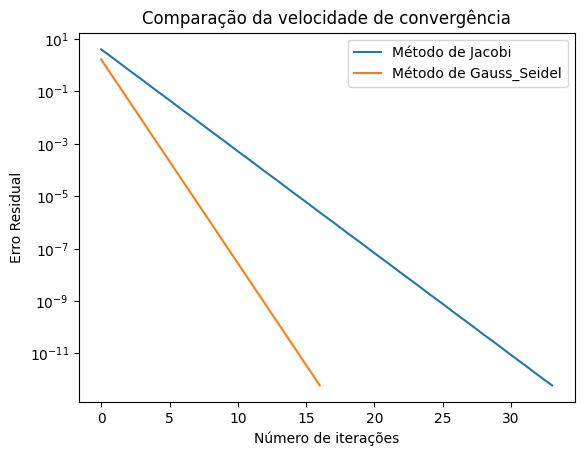

Resposta correta: [2. 1.]
Solução encontrada em cada método:
Jacobi: [2. 1.]
Gauss_Seidel: [2. 1.]


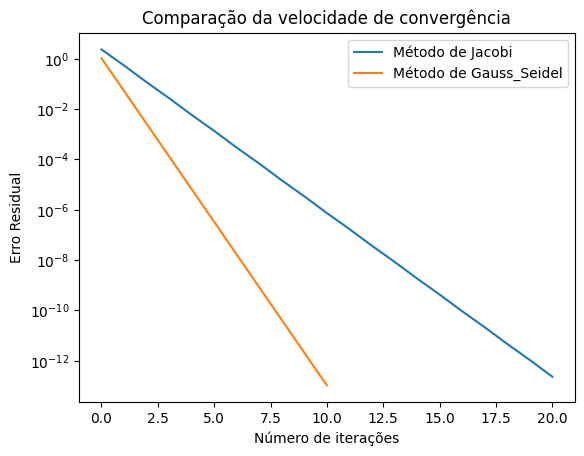

Resposta correta: [ 3. -1.]
Solução encontrada em cada método:
Jacobi: [ 3. -1.]
Gauss_Seidel: [ 3. -1.]


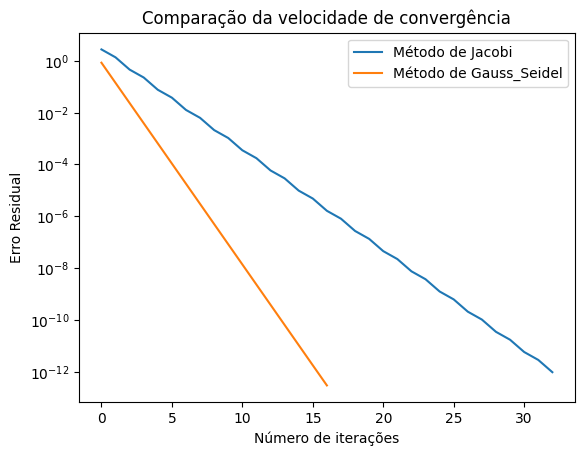

In [5]:
b_1, A_1 = np.array([6, 8]), np.array([[4,1],[2,3]])
b_2, A_2 = np.array([9, 6]), np.array([[5,-1],[1,4]])
b_3, A_3 = np.array([8, 1]), np.array([[3,1],[1,2]])

comparar_metodos_b(A_1, b_1)
comparar_metodos_b(A_2, b_2)
comparar_metodos_b(A_3, b_3)

## Testes para matrizes 3x3

Resposta correta: [1. 2. 3.]
Solução encontrada em cada método:
Jacobi: [1. 2. 3.]
Gauss_Seidel: [1. 2. 3.]


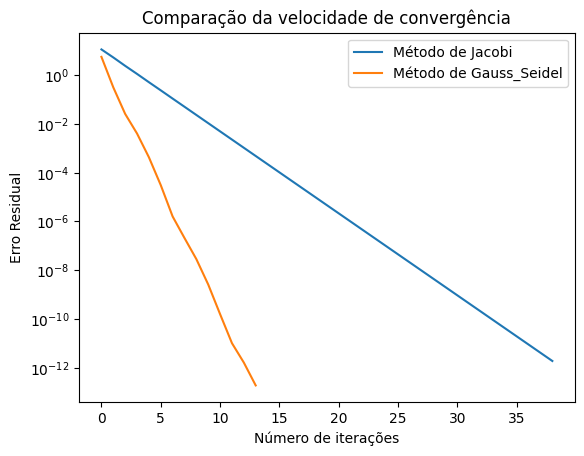

Resposta correta: [2. 1. 1.]
Solução encontrada em cada método:
Jacobi: [2. 1. 1.]
Gauss_Seidel: [2. 1. 1.]


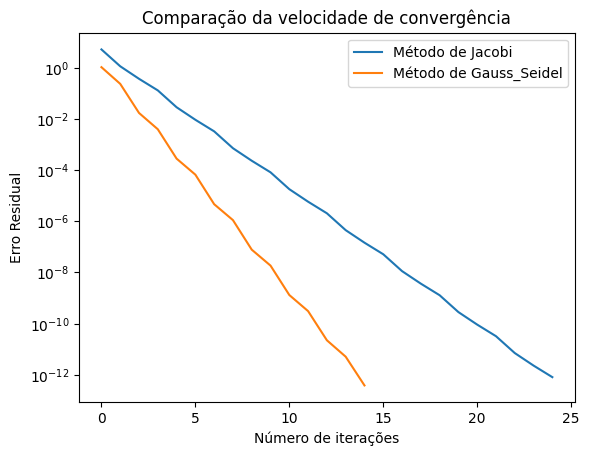

Resposta correta: [ 1. -1.  2.]
Solução encontrada em cada método:
Jacobi: [ 1. -1.  2.]
Gauss_Seidel: [ 1. -1.  2.]


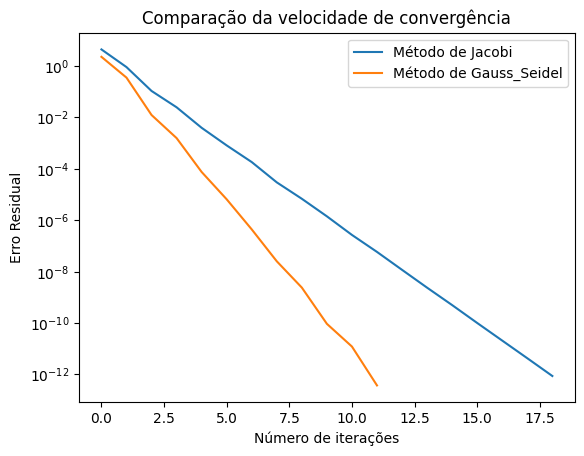

In [6]:
b_1, A_1 = np.array([10, 17, 15]), np.array([[5, 1, 1],[2, 6, 1],[1, 1, 4]])
b_2, A_2 = np.array([8, 6, 11]), np.array([[4, -1, 1],[1, 5, -1],[2, 1, 6]])
b_3, A_3 = np.array([5, -3, 12]), np.array([[6, 1, 0],[2, 7, 1],[1, -1, 5]])

comparar_metodos_b(A_1, b_1)
comparar_metodos_b(A_2, b_2)
comparar_metodos_b(A_3, b_3)

## Comentários
Os dois métodos convergiram à resposta correta em todos os casos. Mas é possível notar que em ambas situações (matrizes 2x2 e matrizes 3x3) o método de Gauss-Siedel foi mais eficiente e convergiu mais rapidamente que o método de Jacobi. Porém, essa diferença, por enquanto nessas dimensões, foi pequena.

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [7]:
# Função para comparar os métodos com matrizes rand(m,m) maiores
def comparar_metodos_c(A, b, max_iter=10000): 
    # Gerando matrizes com diagonal dominante para garantir a convergência dos métodos:
    x_j, errors_j, residual_errors_j = jacobi(A, b, max_iter=max_iter, tol=1e-17)
    x_gs, errors_gs, residual_errors_gs = gauss_seidel(A, b, max_iter=max_iter, tol=1e-17)
    
    # Printando e plotando as informações
    plt.figure()
    sns.lineplot(data=residual_errors_j, label="Método de Jacobi")
    sns.lineplot(data=residual_errors_gs, label="Método de Gauss_Seidel")
    plt.title(f"Velocidade de convergência (shape={A.shape})")
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("Número de Iterações")
    plt.ylabel("Erro Residual")
    plt.legend(loc="upper right")
    plt.show()

## Matrizes maiores com diagonal dominante

In [ ]:
def get_mat_diag_dom(size):
    A = np.random.rand(size, size)
    
    # Tornando a diagonal dominante
    for i in range(size):
        A[i,i] += np.sum(np.abs(A[i,:]))
        
    return A

# Para garantir que b esteja no espaço coluna de A
def get_b(A):
    x = np.random.rand(A.shape[0])
    b = A @ x
    return b

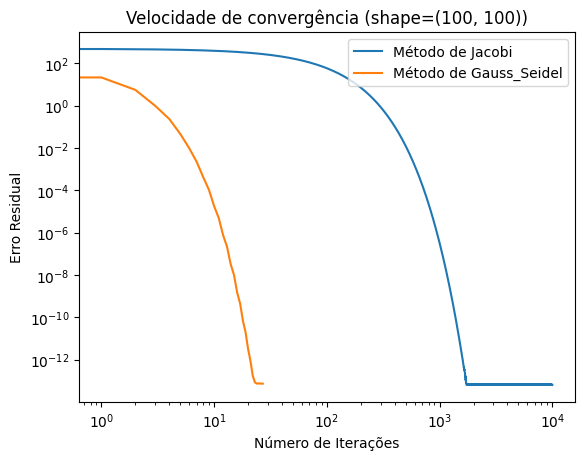

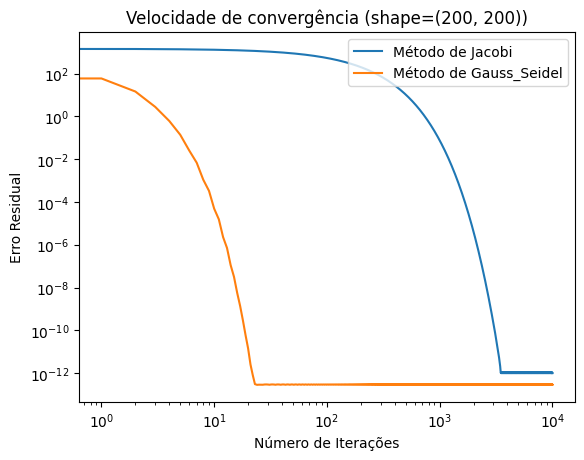

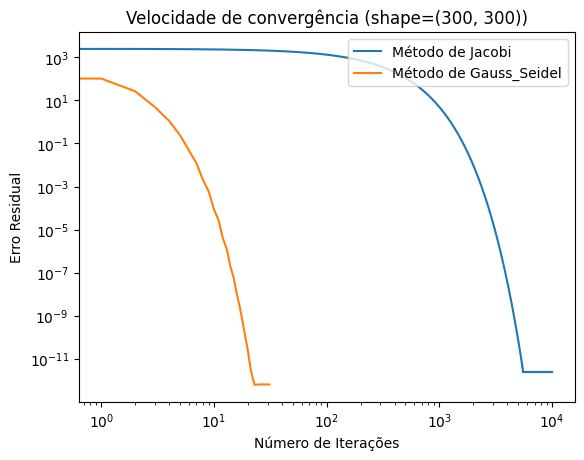

In [9]:
A_1 = get_mat_diag_dom(100)
A_2 = get_mat_diag_dom(200)
A_3 = get_mat_diag_dom(300)

comparar_metodos_c(A_1, get_b(A_1))
comparar_metodos_c(A_2, get_b(A_2))
comparar_metodos_c(A_3, get_b(A_3))

## Matrizes maiores do tipo ```rand(m,m)```

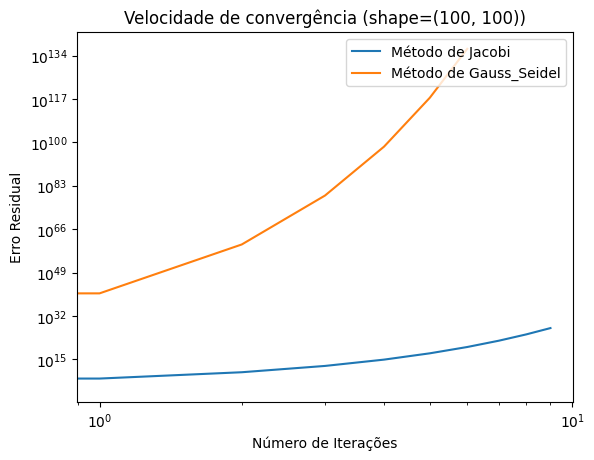

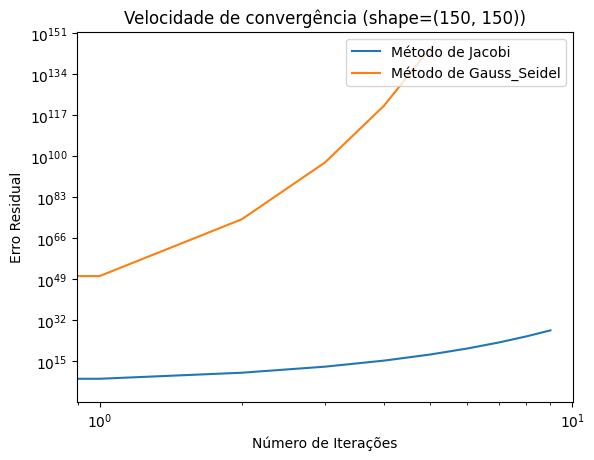

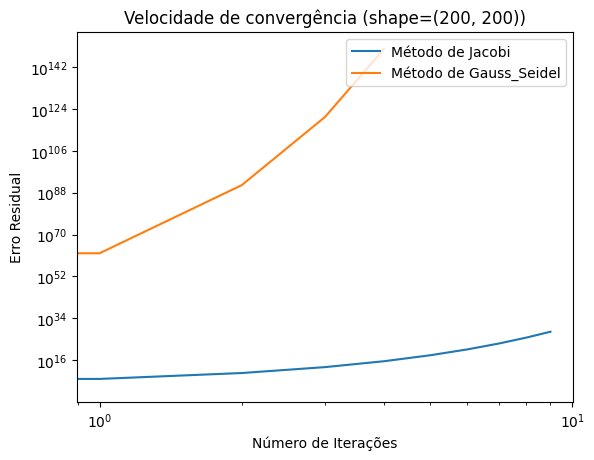

In [14]:
b_1, A_1 = np.random.rand(100), np.random.rand(100, 100)
b_2, A_2 = np.random.rand(150), np.random.rand(150, 150)
b_3, A_3 = np.random.rand(200), np.random.rand(200, 200)

comparar_metodos_c(A_1, get_b(A_1), max_iter=10)
comparar_metodos_c(A_2, get_b(A_2), max_iter=10)
comparar_metodos_c(A_3, get_b(A_3), max_iter=10)

## Comentários
Em geral, percebemos que se nós não normalizarmos a matriz randomizada para ter diagonal dominante, os métodos irão divergir. Ao contrário, se a matriz tiver diagonal dominante, vemos que os métodos continuam funcionando e o Gauss_Seidel continua apresentando uma eficiência muito melhor que o Jacobi (este último leva milhares de iterações a mais para convergir até certo erro de tolerância que nos testes foi de $10^{-12}$)

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

## Encontrando o $k(m)$:

Somando $m - 1$ variáveis aleatórias em distribuição normal ao redor do 0 com desvio padrão igual a 1, a tendência é que o resultado some 0, mas com desvio padrão $\sqrt{m - 1}$. Porém, se queremos que 95% das matrizes convirjam, não podemos apenas somar $\sqrt{m - 1}$ à diagonal, pois isso é uma "média". Assim, vamos encontrar alguma constante $C$ tal que adicionar $C \cdot \sqrt{m - 1}$ à cada elemento da diagonal faça a matriz convergir em 95% dos casos.

In [9]:
# Função que recebe a dimensão (m) das matrizes que vão ser testadas,
# a constante (C) que vamos testar para analisar o percentual de convergência
# e, possivelmente, o número de testes (N) que vamos fazer
def get_perc_conv(m, C, N=300):
    # Contando o número de convergências
    convergencias_jacobi = 0
    convergencias_gs = 0
        
    # Definindo o k(m) a ser testado
    k = C * np.sqrt(m - 1)
    
    # Criando as matrizes que vamos testar
    M_tests = np.random.randn(N, m, m)
    
    # Realizando os testes
    for i in range(N):
        M = M_tests[i]
        
        # A diagonal da matriz final A será a diagonal de M somada a k
        diag_A = np.diag(M) + k
        
        # Matriz D (diagonal)
        D = np.diag(diag_A)
        
        # Matrizes L e U
        L = np.tril(M, -1)
        U = np.triu(M, 1)
        
        try:
        
            # Matriz de iteração de Jacobi: M_J = - D^(-1) (L + U)
            D_inv = np.diag(1.0 / diag_A)
            M_J = -D_inv @ (L + U)
        
            # Matriz de iteração de Gauss-Seidel: M_GS = - (D + L)^(-1) U
            D_plus_L_inv = np.linalg.inv(D + L)
            M_GS = -D_plus_L_inv @ U
        
            # Verifica a convergência calculando o raio espectral,
            # pois temos que usar a condição necessária, já que com a condição
            # suficiente apenas de ter a diagonal dominante pode nos levar a erros
            raio_espectral_J = np.max(np.abs(np.linalg.eigvals(M_J)))
            raio_espectral_GS = np.max(np.abs(np.linalg.eigvals(M_GS)))
        
            if raio_espectral_J < 1:
                convergencias_jacobi += 1
            
            if raio_espectral_GS < 1:
                convergencias_gs += 1
        
        except:
            # Se a matriz D+L for singular, a tentativa de inversão causa o erro de LinAlgError.
            # Como ela não converge, então só pula para a próxima matriz
            pass
            
    # Retorna a razão de convergência para ambos os métodos
    return convergencias_jacobi / N, convergencias_gs / N

In [17]:
# Tamanhos de matrizes que vamos testar
m_valores = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Valores de C que vamos testar
# Estamos analisando até 3 vezes o desvio padrão
C_testes = np.linspace(0.1, 3, 30)

k_otimos = [] # Primeiro k(m) que faz convergir em mais de 95%
c_encontrados = []

for m in m_valores:
    C_otimo_J = 0
    C_otimo_GS = 0
    
    for C in C_testes:
        perc_jacobi, perc_gs = get_perc_conv(m, C, N=300)
        
        # Guarda o primeiro C que faz Gauss-Seidel bater 95%
        if perc_gs >= 0.95 and C_otimo_GS == 0:
            C_otimo_GS = C
            
        # Guarda o primeiro C que faz Jacobi bater 95%
        if perc_jacobi >= 0.95 and C_otimo_J == 0:
            C_otimo_J = C
            
        # Se já achou para os dois, paramos a busca para este m
        if C_otimo_J != 0 and C_otimo_GS != 0:
            break
            
    C_otimo = max(C_otimo_J, C_otimo_GS)
     
    k_necessario = C_otimo * np.sqrt(m - 1)
    
    c_encontrados.append(C_otimo)
    k_otimos.append(k_necessario)

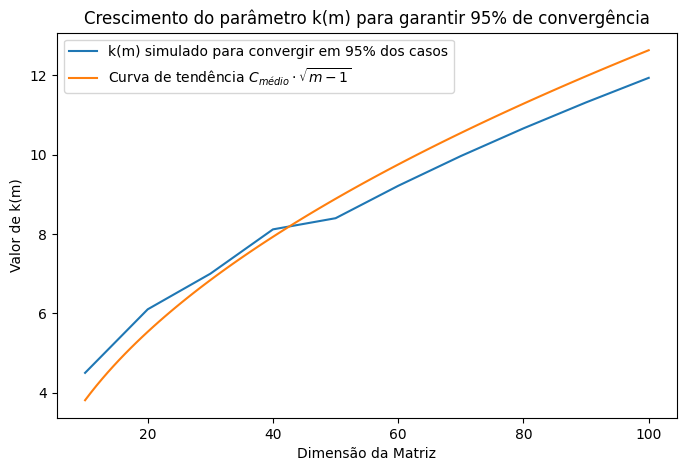

C médio:  1.27


In [18]:
# Média da constante C que funciona para vários valores de m
C_medio = np.mean(c_encontrados)

plt.figure(figsize=(8, 5))

# Plottando os valores da simulação
plt.plot(m_valores, k_otimos, label=r"k(m) simulado para convergir em 95% dos casos")

# Plottando uma curva de tendência com o C médio da simulação
m_continuo = np.linspace(m_valores[0], m_valores[-1], 100)
curva_teorica = C_medio * np.sqrt(m_continuo - 1)

plt.plot(m_continuo, curva_teorica, label=r"Curva de tendência $C_{médio} \cdot \sqrt{m - 1}$")

plt.title(r"Crescimento do parâmetro k(m) para garantir 95% de convergência")
plt.xlabel("Dimensão da Matriz")
plt.ylabel("Valor de k(m)")
plt.legend()

plt.show()

print("C médio: ", round(C_medio, 2))

## Comentários sobre o $k(m)$
Percebemos que, para os métodos convergirem para 95% dos casos com matrizes do tipo ```randn(m,m)```, $k(m)$ é uma função raiz quadrada de $\sqrt{m - 1}$ (como explicado anteriormente) multiplicada por uma constante $C \approx 1.3$, que achamos empiricamente.

## Analisando a velocidade de convergência:

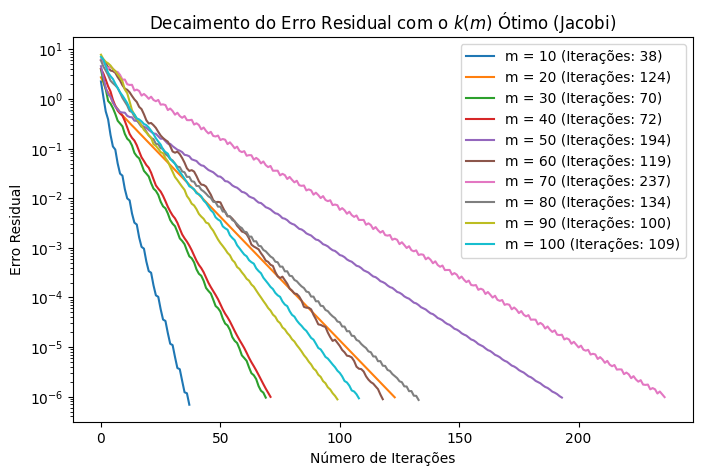

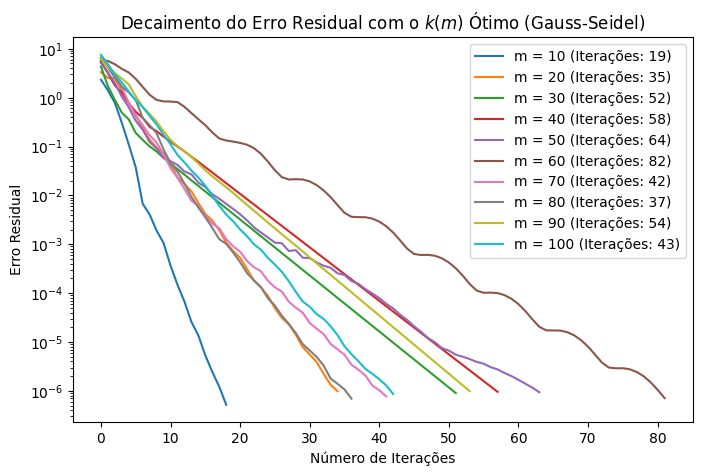

In [30]:
iteracoes_necessarias_jacobi = []

plt.figure(figsize=(8,5))

for i in range(len(m_valores)):
    
    # Criando a matriz no limiar exato
    M = np.random.randn(m_valores[i], m_valores[i])
    A = M.copy()
    np.fill_diagonal(A, np.diag(M) + k_otimos[i])
    
    # Criando um b no espaço coluna de A
    x = np.random.rand(m_valores[i])
    b = A @ x
    
    x_final, lista_erros, lista_passos = jacobi(A, b, tol=1e-6, max_iter=5000)
    
    num_iters = lista_erros.size
    iteracoes_necessarias_jacobi.append(num_iters)
    
    # Adiciona o decaimento do erro do m no gráfico
    plt.plot(lista_erros, label=f'm = {m_valores[i]} (Iterações: {num_iters})')


plt.yscale("log")
plt.title(f"Decaimento do Erro Residual com o $k(m)$ Ótimo (Jacobi)")
plt.xlabel("Número de Iterações")
plt.ylabel("Erro Residual")
plt.legend()

#==================================================================================

iteracoes_necessarias_gs = []

plt.figure(figsize=(8,5))

for i in range(len(m_valores)):
    
    # Criando a matriz no limiar exato
    M = np.random.randn(m_valores[i], m_valores[i])
    A = M.copy()
    np.fill_diagonal(A, np.diag(M) + k_otimos[i])
    
    # Criando um b no espaço coluna de A
    x = np.random.rand(m_valores[i])
    b = A @ x
    
    x_final, lista_erros, lista_passos = gauss_seidel(A, b, tol=1e-6, max_iter=5000)
    
    num_iters = lista_erros.size
    iteracoes_necessarias_gs.append(num_iters)
    
    # Adiciona o decaimento do erro do m no gráfico
    plt.plot(lista_erros, label=f'm = {m_valores[i]} (Iterações: {num_iters})')


plt.yscale("log")
plt.title(f"Decaimento do Erro Residual com o $k(m)$ Ótimo (Gauss-Seidel)")
plt.xlabel("Número de Iterações")
plt.ylabel("Erro Residual")
plt.legend()

plt.show()

## Comentários sobre a velocidade de convergência:
Comparando com os testes dos itens anteriores em que usamos matrizes com diagonais dominantes, percebemos que operar próximo do limiar do $k(m)$ ótimo faz com que o sistema fique estranho, indefinido. Isso porque podemos notar que os métodos tomam muito mais iterações para chegar ao mesmo erro residual. Além de que nessa situação não é tão clara uma relação do tamanho $m$ da matriz com o número de iterações requeridas, já que matrizes menores tomam muito mais iterações em alguns casos.

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

(Explique suas ideias, verifique abaixo)

In [12]:
# Código

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

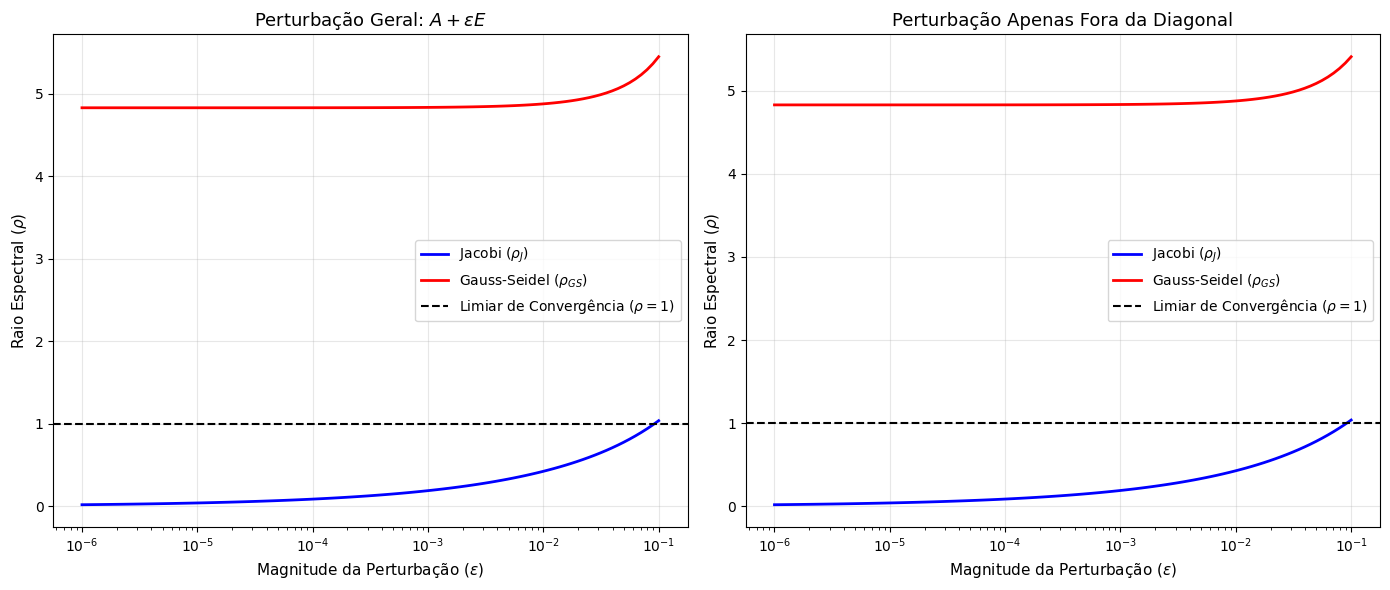

In [2]:
# Código
import numpy as np
import matplotlib.pyplot as plt

# Definição da matriz A (Questão 1e)
A = np.array([
    [ 1, -2,  2,  0],
    [-1,  1, -1,  0],
    [-2, -2,  1,  0],
    [ 0,  0,  0,  1]
], dtype=float)

def calcular_raios_espectrais(M):
    """Calcula o raio espectral da matriz de iteração de Jacobi e Gauss-Seidel."""
    D_vetor = np.diag(M)
    
    # Prevenção contra singularidade na diagonal
    if np.any(np.abs(D_vetor) < 1e-14):
        return np.nan, np.nan
        
    D = np.diag(D_vetor)
    L = np.tril(M, -1)
    U = np.triu(M, 1)
    
    # Método de Jacobi: R_J = -D^{-1}(L+U)
    D_inv = np.diag(1.0 / D_vetor)
    R_J = -D_inv @ (L + U)
    rho_J = np.max(np.abs(np.linalg.eigvals(R_J)))
    
    # Método de Gauss-Seidel: R_GS = -(D+L)^{-1}U
    DL_inv = np.linalg.inv(D + L)
    R_GS = -DL_inv @ U
    rho_GS = np.max(np.abs(np.linalg.eigvals(R_GS)))
    
    return rho_J, rho_GS

# Valores de perturbação epsilon numa escala logarítmica (de 10^-6 a 10^-1)
epsilons = np.logspace(-6, -1, 100)

# Gerar matrizes de perturbação base (fixas para obter curvas suaves)
np.random.seed(42)
E_geral = np.random.randn(4, 4)

E_fora_diag = E_geral.copy()
np.fill_diagonal(E_fora_diag, 0)

# Arrays para armazenar os resultados
rho_J_geral, rho_GS_geral = [], []
rho_J_fora_diag, rho_GS_fora_diag = [], []

for eps in epsilons:
    # 1. Perturbação Geral
    A_geral = A + eps * E_geral
    rj_g, rgs_g = calcular_raios_espectrais(A_geral)
    rho_J_geral.append(rj_g)
    rho_GS_geral.append(rgs_g)
    
    # 2. Perturbação Fora da Diagonal
    A_fora_diag = A + eps * E_fora_diag
    rj_fd, rgs_fd = calcular_raios_espectrais(A_fora_diag)
    rho_J_fora_diag.append(rj_fd)
    rho_GS_fora_diag.append(rgs_fd)

# ==========================================
# Visualização Gráfica
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Perturbação Geral
ax1.plot(epsilons, rho_J_geral, label='Jacobi ($\\rho_J$)', color='blue', linewidth=2)
ax1.plot(epsilons, rho_GS_geral, label='Gauss-Seidel ($\\rho_{GS}$)', color='red', linewidth=2)
ax1.axhline(1, color='black', linestyle='--', label='Limiar de Convergência ($\\rho = 1$)')
ax1.set_xscale('log')
ax1.set_title('Perturbação Geral: $A + \\epsilon E$', fontsize=13)
ax1.set_xlabel('Magnitude da Perturbação ($\\epsilon$)', fontsize=11)
ax1.set_ylabel('Raio Espectral ($\\rho$)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Perturbação Fora da Diagonal
ax2.plot(epsilons, rho_J_fora_diag, label='Jacobi ($\\rho_J$)', color='blue', linewidth=2)
ax2.plot(epsilons, rho_GS_fora_diag, label='Gauss-Seidel ($\\rho_{GS}$)', color='red', linewidth=2)
ax2.axhline(1, color='black', linestyle='--', label='Limiar de Convergência ($\\rho = 1$)')
ax2.set_xscale('log')
ax2.set_title('Perturbação Apenas Fora da Diagonal', fontsize=13)
ax2.set_xlabel('Magnitude da Perturbação ($\\epsilon$)', fontsize=11)
ax2.set_ylabel('Raio Espectral ($\\rho$)', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(Comentários)